In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib

In [11]:
df = pd.read_csv(r'D:\Academic Competition\Rumble NDC\classification-rumble-ndc-2025\train.csv')

In [ ]:
# 1. Ekstrak angka (bisa ada desimal) dan non-angka (unit) menggunakan regex
extract = df['value_with_unit'].astype(str).str.extract(r'([\d\.]+)\s*([^\d]+)')
df['value_num'] = extract[0].astype(float)

# 2. Bersihkan spasi di unit, dan ubah ke kategori (bila perlu)
df['unit'] = extract[1].str.strip()

# Contoh hasil:
#    value_with_unit   value_num   unit
# 0  "0.1 µg/l"        0.1         "µg/l"
# 1  "1.7 µg/l"        1.7         "µg/l"
# 2  "7.7 %"           7.7         "%"

# 3. (Opsional) Jika unit berbeda-beda dan ingin disamaratakan:
#    misal konversi µg/l ke mg/L, dsb. Bisa ditambah logika di sini.

# 4. Setelah itu, drop kolom lama:
df = df.drop(columns=['value_with_unit', 'unit'])

In [13]:
# 1. Pecah berdasarkan " - " (strip dengan spasi) antara timestamp dan musim
df[['datetime_str', 'season']] = df['time_season'].str.split(' - ', expand=True)

# 2. Konversi datetime_str ke tipe datetime
df['datetime'] = pd.to_datetime(df['datetime_str'])

# 3. Ambil tanggal dan jam secara terpisah
df['date'] = df['datetime'].dt.date
df['hour'] = df['datetime'].dt.hour

# (Opsional) Drop kolom lama jika sudah tidak perlu
df = df.drop(columns=['time_season', 'datetime_str', 'datetime'])

In [14]:
import pandas as pd
import numpy as np

# Scikit-learn imports for multivariate imputation
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder

In [15]:
# 3. Identify column types
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

# 4. Specify which categorical columns are truly ordinal
#    Here, 'pollution_risk' has an inherent order Low < Medium < High
ordinal_cols = ['pollution_risk']
ordinal_categories = [
    ['Very Low', 'Low', 'Medium', 'High']
]
# Everything else remains nominal
nominal_cols = [c for c in cat_cols if c not in ordinal_cols]

# 5. Encode ordinal columns as integers (so MICE can treat them numerically)
ord_encoder = OrdinalEncoder(categories=ordinal_categories, dtype=float, handle_unknown='use_encoded_value', unknown_value=np.nan) # Modified line
df_ord = pd.DataFrame(
    ord_encoder.fit_transform(df[ordinal_cols]),
    columns=ordinal_cols,
    index=df.index
)

# 6. For nominal columns, do a simple most-frequent imputing up front
nominal_imputer = SimpleImputer(strategy='most_frequent')
df_nom = pd.DataFrame(
    nominal_imputer.fit_transform(df[nominal_cols]),
    columns=nominal_cols,
    index=df.index
)

In [16]:
# 7. Build a DataFrame of everything we will impute jointly:
#    – all numeric columns
#    – the encoded ordinal columns
joint_cols = num_cols + ordinal_cols
df_joint = pd.concat([df[num_cols], df_ord], axis=1)

# 8. Set up the IterativeImputer (MICE) with a RandomForestRegressor
mice_imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=20, random_state=42),
    max_iter=10,
    initial_strategy='median',
    imputation_order='ascending',
    random_state=42
)

# 9. Fit & transform
df_joint_imputed = pd.DataFrame(
    mice_imputer.fit_transform(df_joint),
    columns=joint_cols,
    index=df.index
)

# 10. Split the joint result back into numeric + ordinal
df_num_imputed = df_joint_imputed[num_cols]

c:\Users\A S U S\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [17]:
# 11. Round & inverse-encode ordinal columns
df_ord_imputed_raw = df_joint_imputed[ordinal_cols].round().astype(int)
df_ord_imputed = pd.DataFrame(
    ord_encoder.inverse_transform(df_ord_imputed_raw),
    columns=ordinal_cols,
    index=df.index
)

# 12. Reconstruct the final DataFrame
df_imputed = pd.concat([df_num_imputed, df_ord_imputed, df_nom], axis=1)

# 13. Check that no missing remains
print("Missing values before:", df.isnull().sum().sum())
print("Missing values after: ", df_imputed.isnull().sum().sum())

Missing values before: 168134
Missing values after:  0


In [19]:
# Buat fitur baru pada df_imputed
df_imputed['temp_humidity_ratio'] = df_imputed['temperature_avg'] / (df_imputed['humidity_pct'] + 1)
df_imputed['green_cover'] = df_imputed['forest_pct'] + df_imputed['grassland_pct'] + df_imputed['wetland_pct']
df_imputed['built_cover'] = df_imputed['urban_pct'] + df_imputed['barren_pct']

In [20]:
# --- 1. Climate Stress Index ---
df_imputed['climate_stress_index'] = (
    df_imputed['temperature_avg'] * (1 - df_imputed['humidity_pct'] / 100) +
    abs(df_imputed['drought_index']) +
    (df_imputed['extreme_precip_days'] / 10)
)

df_imputed['green_cover'] = df_imputed['forest_pct'] + df_imputed['grassland_pct'] + df_imputed['wetland_pct']

# --- 3. total_industrial_risk ---
df_imputed['total_industrial_risk'] = (
    df_imputed['hg_impact'] + df_imputed['pb_impact'] +
    df_imputed['ind_risk_score'] + df_imputed['ind_count']
)

# --- 4. soil_buffer_ratio ---
df_imputed['soil_buffer_ratio'] = df_imputed['soil_perm'] / (df_imputed['total_industrial_risk'] + 1)


# --- 6. is_verified_measurement ---
df_imputed['is_verified_measurement'] = (
    df_imputed['is_referenced_method'].astype(int) & df_imputed['validated_results'].astype(int)
)

# --- Hapus fitur yang sudah digabungkan ---
df_imputed.drop([
    'forest_pct', 'grassland_pct', 'wetland_pct', 'urban_pct', 'barren_pct',
    'hg_impact', 'pb_impact', 'ind_risk_score', 'ind_count',
    'soil_perm',
    'is_referenced_method', 'validated_results'
], axis=1, inplace=True)

In [21]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Identifikasi kolom
numeric_cols = df_imputed.select_dtypes(include=['int64', 'float64']).columns.tolist()
object_cols  = df_imputed.select_dtypes(include=['object']).columns.tolist()

# 2. Standardisasi numerik
scaler = StandardScaler()
df_imputed[numeric_cols] = scaler.fit_transform(df_imputed[numeric_cols])

# 3. Label Encoding objek
label_encoders = {}
for col in object_cols:
    le = LabelEncoder()
    df_imputed[col] = le.fit_transform(df_imputed[col].astype(str))
    label_encoders[col] = le  # Simpan encoder untuk inverse transform jika perlu

# 4. Cek hasil
print("Numeric columns standardized:", numeric_cols)
print("Object columns label-encoded:", object_cols)

Numeric columns standardized: ['Latitude', 'Longitude', 'Depth', 'temperature_avg', 'rainfall_mm', 'humidity_pct', 'pressure_hPa', 'drought_index', 'extreme_precip_days', 'agriculture_pct', 'water_pct', 'frag_index', 'value_num', 'hour', 'temp_humidity_ratio', 'green_cover', 'built_cover', 'climate_stress_index', 'total_industrial_risk', 'soil_buffer_ratio']
Object columns label-encoded: ['pollution_risk', 'Station Code', 'Parameter Code', 'Analysis Method Code', 'Value Flags', 'Data Quality', 'Dataset_Source', 'param_category', 'country_code', 'sampling_method', 'water_body_type', 'analytical_program', 'testing_laboratory', 'sampling_weather', 'regulatory_framework', 'land_use_impact', 'season', 'date']


In [22]:
from sklearn.utils import resample

# Pisahkan data berdasarkan kelas
df_0 = df_imputed[df_imputed['Data Quality'] == 0]
df_1 = df_imputed[df_imputed['Data Quality'] == 1]
df_2 = df_imputed[df_imputed['Data Quality'] == 2]
df_3 = df_imputed[df_imputed['Data Quality'] == 3]

# Tentukan jumlah target sample (misal setara dengan kelas mayoritas: 10,133)
target_n = 7500

# Oversampling kelas minoritas
df_1_upsampled = resample(df_1, replace=True, n_samples=target_n, random_state=42)
df_2_upsampled = resample(df_2, replace=True, n_samples=target_n, random_state=42)
df_3_upsampled = resample(df_3, replace=True, n_samples=target_n, random_state=42)

# Gabungkan semua kelas menjadi satu dataset seimbang
train_balanced = pd.concat([df_0, df_1_upsampled, df_2_upsampled, df_3_upsampled])

# Shuffle data (opsional tapi disarankan)
train_balanced = train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Cek distribusi setelah diimbangi
print(train_balanced['Data Quality'].value_counts())

Data Quality
0    10133
1     7500
3     7500
2     7500
Name: count, dtype: int64


In [23]:
# Daftar fitur yang dipilih (berdasarkan nilai yang kamu tampilkan)
selected_features = [
    'Longitude', 'Latitude', 'date', 'Station Code',
    'green_cover', 'water_pct', 'agriculture_pct', 'frag_index',
    'Analysis Method Code', 'built_cover', 'soil_buffer_ratio',
    'humidity_pct', 'hour', 'value_num', 'Depth'
]

# Membuat subset DataFrame berdasarkan fitur terpilih
belance = train_balanced[selected_features]

In [ ]:
# Daftar fitur yang dipilih (berdasarkan nilai yang kamu tampilkan)
selected_feature = [
    'Longitude', 'Latitude', 'date', 'Station Code',
    'green_cover', 'water_pct'
]

# Membuat subset DataFrame berdasarkan fitur terpilih
belanc = train_balanced[selected_feature]

In [105]:
# Daftar fitur yang dipilih (berdasarkan nilai yang kamu tampilkan)
selected_featu = [
    'Longitude', 'Latitude', 'date'
]

# Membuat subset DataFrame berdasarkan fitur terpilih
belan = train_balanced[selected_featu]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE

In [106]:
X = belan
y = train_balanced['Data Quality'].values

In [107]:
# Bagi data terlebih dahulu (jika diperlukan)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=42, test_size=0.2)

In [108]:
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import pandas as pd

In [109]:
from catboost import CatBoostClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# --- 1. Hitung class_weights otomatis ---
classes = np.unique(y_train)
class_weights_array = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights_dict = dict(zip(classes, class_weights_array))
print("Class Weights:", class_weights_dict)

Class Weights: {0: 0.8051443375277573, 1: 1.08775, 2: 1.08775, 3: 1.08775}


In [110]:
# --- CatBoost ---
param_grid_cb = {
    'iterations': [200, 500],
    'depth': [6, 10],
    'learning_rate': [0.01, 0.1],
    'l2_leaf_reg': [3, 5]
}
grid_cb = GridSearchCV(
    estimator=CatBoostClassifier(
        loss_function='MultiClass',
        class_weights=list(class_weights_dict.values()),
        random_state=42,
        verbose=0
    ),
    param_grid=param_grid_cb,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=2
)
grid_cb.fit(X_train, y_train)
y_pred_cb = grid_cb.best_estimator_.predict(X_test)

Fitting 5 folds for each of 16 candidates, totalling 80 fits


In [111]:
best_cbbb = grid_cb.best_estimator_

In [112]:
best_cbbb.feature_names_

['Longitude', 'Latitude', 'date']

In [65]:
# --- LightGBM ---
param_grid_lgbm = {
    'n_estimators': [200, 500],
    'max_depth': [6, 10],
    'learning_rate': [0.01, 0.1],
    'reg_lambda': [3, 5]
}
grid_lgbm = GridSearchCV(
    estimator=LGBMClassifier(
        class_weight=class_weights_dict,
        random_state=42
    ),
    param_grid=param_grid_lgbm,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=2
)
grid_lgbm.fit(X_train, y_train)
y_pred_lgbm = grid_lgbm.best_estimator_.predict(X_test)

# --- XGBoost ---
param_grid_xgb = {
    'n_estimators': [200, 500],
    'max_depth': [6, 10],
    'learning_rate': [0.01, 0.1],
    'reg_lambda': [3, 5]
}
grid_xgb = GridSearchCV(
    estimator=XGBClassifier(
        objective='multi:softmax',
        num_class=len(set(y_train)),
        use_label_encoder=False,
        eval_metric='mlogloss',
        random_state=42
    ),
    param_grid=param_grid_xgb,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=2
)
grid_xgb.fit(X_train, y_train)
y_pred_xgb = grid_xgb.best_estimator_.predict(X_test)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001472 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1528
[LightGBM] [Info] Number of data points in the train set: 26106, number of used features: 6
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

c:\Users\A S U S\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py:158: UserWarning: [01:58:25] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


In [66]:
# Evaluasi f1_macro
f1_cb = f1_score(y_test, y_pred_cb, average='macro')
f1_lgbm = f1_score(y_test, y_pred_lgbm, average='macro')
f1_xgb = f1_score(y_test, y_pred_xgb, average='macro')

# Ringkasan hasil
results = pd.DataFrame({
    "Model": ["CatBoost", "LightGBM", "XGBoost"],
    "Best Params": [
        grid_cb.best_params_,
        grid_lgbm.best_params_,
        grid_xgb.best_params_
    ],
    "F1 Macro Score": [f1_cb, f1_lgbm, f1_xgb]
})

print("\n=== Ringkasan Hasil GridSearch ===")
print(results)

# Optional: Print laporan lengkap
print("\n=== Classification Report: CatBoost ===")
print(classification_report(y_test, y_pred_cb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_cb))

print("\n=== Classification Report: LightGBM ===")
print(classification_report(y_test, y_pred_lgbm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lgbm))

print("\n=== Classification Report: XGBoost ===")
print(classification_report(y_test, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))


=== Ringkasan Hasil GridSearch ===
      Model                                        Best Params  F1 Macro Score
0  CatBoost  {'depth': 10, 'iterations': 500, 'l2_leaf_reg'...        0.990716
1  LightGBM  {'learning_rate': 0.1, 'max_depth': 6, 'n_esti...        0.994344
2   XGBoost  {'learning_rate': 0.1, 'max_depth': 6, 'n_esti...        0.994196

=== Classification Report: CatBoost ===
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      2027
           1       0.98      1.00      0.99      1500
           2       1.00      1.00      1.00      1500
           3       0.99      0.99      0.99      1500

    accuracy                           0.99      6527
   macro avg       0.99      0.99      0.99      6527
weighted avg       0.99      0.99      0.99      6527


Confusion Matrix:
 [[1977   35    5   10]
 [   0 1500    0    0]
 [   0    0 1500    0]
 [  14    0    0 1486]]

=== Classification Report: LightGBM ===
              prec

In [79]:
bestt_lgbm = grid_lgbm.best_estimator_
bestt_xgb = grid_xgb.best_estimator_

In [ ]:
from sklearn.ensemble import VotingClassifier

# Buat ulang model terbaik dari hasil GridSearch
best_cb = grid_cb.best_estimator_
best_lgbm = grid_lgbm.best_estimator_
best_xgb = grid_xgb.best_estimator_

# Voting Ensemble
ensemble_model = VotingClassifier(
    estimators=[
        ('catboost', best_cb),
        ('lightgbm', best_lgbm),
        ('xgboost', best_xgb)
    ],
    voting='soft',  # pakai probabilitas kelas
    n_jobs=-1
)

# Training
ensemble_model.fit(X_train, y_train)

# Prediksi
y_pred_ensemble = ensemble_model.predict(X_test)

     Feature  Importance
0  Longitude   37.738146
2       date   31.314539
1   Latitude   30.947315


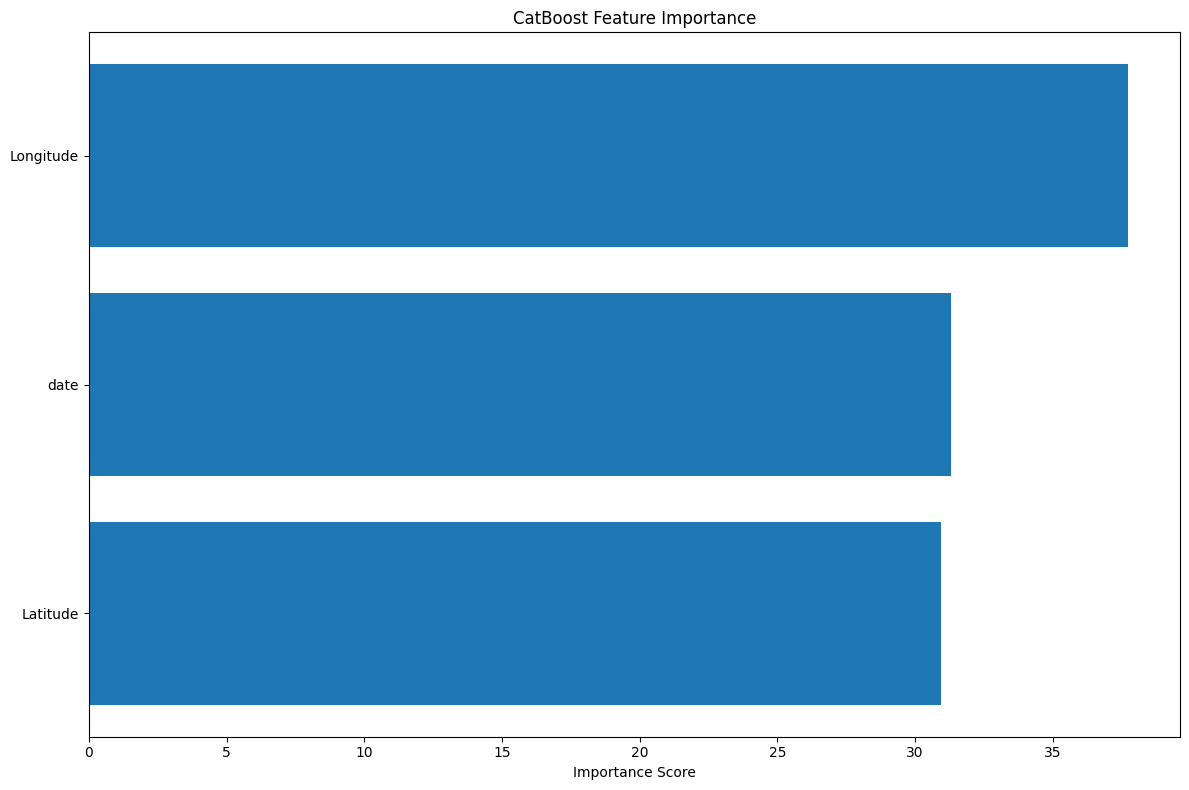

In [113]:

# Ambil semua nama fitur kecuali target
feature_names = belan.columns

# Ambil feature importance dari model terbaik
importances = best_cbbb.get_feature_importance()

# Buat DataFrame untuk visualisasi
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Tampilkan hasil
print(feature_importance_df)

# Visualisasi
plt.figure(figsize=(12, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel("Importance Score")
plt.title("CatBoost Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
dt = pd.read_csv(r'D:\Academic Competition\Rumble NDC\classification-rumble-ndc-2025\test.csv')

In [ ]:
# 1. Ekstrak angka (bisa ada desimal) dan non-angka (unit) menggunakan regex
extract = dt['value_with_unit'].astype(str).str.extract(r'([\d\.]+)\s*([^\d]+)')
dt['value_num'] = extract[0].astype(float)

# 2. Bersihkan spasi di unit, dan ubah ke kategori (bila perlu)
dt['unit'] = extract[1].str.strip()

# Contoh hasil:
#    value_with_unit   value_num   unit
# 0  "0.1 µg/l"        0.1         "µg/l"
# 1  "1.7 µg/l"        1.7         "µg/l"
# 2  "7.7 %"           7.7         "%"

# 3. (Opsional) Jika unit berbeda-beda dan ingin disamaratakan:
#    misal konversi µg/l ke mg/L, dsb. Bisa ditambah logika di sini.

# 4. Setelah itu, drop kolom lama:
dt = dt.drop(columns=['value_with_unit', 'unit'])

In [ ]:
# 1. Pecah berdasarkan " - " (strip dengan spasi) antara timestamp dan musim
dt[['datetime_str', 'season']] = dt['time_season'].str.split(' - ', expand=True)

# 2. Konversi datetime_str ke tipe datetime
dt['datetime'] = pd.to_datetime(dt['datetime_str'])

# 3. Ambil tanggal dan jam secara terpisah
dt['date'] = dt['datetime'].dt.date
dt['hour'] = dt['datetime'].dt.hour

# (Opsional) Drop kolom lama jika sudah tidak perlu
dt = dt.drop(columns=['time_season', 'datetime_str', 'datetime'])

In [ ]:
# 3. Identify column types
num_cols = dt.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = dt.select_dtypes(include=['object']).columns.tolist()

# 4. Specify which categorical columns are truly ordinal
#    Here, 'pollution_risk' has an inherent order Low < Medium < High
ordinal_cols = ['pollution_risk']
ordinal_categories = [
    ['Very Low', 'Low', 'Medium', 'High']
]
# Everything else remains nominal
nominal_cols = [c for c in cat_cols if c not in ordinal_cols]

# 5. Encode ordinal columns as integers (so MICE can treat them numerically)
ord_encoder = OrdinalEncoder(categories=ordinal_categories, dtype=float, handle_unknown='use_encoded_value', unknown_value=np.nan) # Modified line
dt_ord = pd.DataFrame(
    ord_encoder.fit_transform(dt[ordinal_cols]),
    columns=ordinal_cols,
    index=dt.index
)

# 6. For nominal columns, do a simple most-frequent imputing up front
nominal_imputer = SimpleImputer(strategy='most_frequent')
dt_nom = pd.DataFrame(
    nominal_imputer.fit_transform(dt[nominal_cols]),
    columns=nominal_cols,
    index=dt.index
)

In [ ]:
joint_cols = num_cols + ordinal_cols
dt_joint = pd.concat([dt[num_cols], dt_ord], axis=1)

# 8. Set up the IterativeImputer (MICE) with a RandomForestRegressor
mice_imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=20, random_state=42),
    max_iter=10,
    initial_strategy='median',
    imputation_order='ascending',
    random_state=42
)

# 9. Fit & transform
dt_joint_imputed = pd.DataFrame(
    mice_imputer.fit_transform(dt_joint),
    columns=joint_cols,
    index=dt.index
)

# 10. Split the joint result back into numeric + ordinal
dt_num_imputed = dt_joint_imputed[num_cols]

c:\Users\A S U S\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [ ]:
# 11. Round & inverse-encode ordinal columns
dt_ord_imputed_raw = dt_joint_imputed[ordinal_cols].round().astype(int)
dt_ord_imputed = pd.DataFrame(
    ord_encoder.inverse_transform(dt_ord_imputed_raw),
    columns=ordinal_cols,
    index=dt.index
)

# 12. Reconstruct the final DataFrame
dt_imputed = pd.concat([dt_num_imputed, dt_ord_imputed, dt_nom], axis=1)

# 13. Check that no missing remains
print("Missing values before:", dt.isnull().sum().sum())
print("Missing values after: ", dt_imputed.isnull().sum().sum())

Missing values before: 71808
Missing values after:  0


In [ ]:
# Buat fitur baru pada dt_imputed
dt_imputed['temp_humidity_ratio'] = dt_imputed['temperature_avg'] / (dt_imputed['humidity_pct'] + 1)
dt_imputed['green_cover'] = dt_imputed['forest_pct'] + dt_imputed['grassland_pct'] + dt_imputed['wetland_pct']
dt_imputed['built_cover'] = dt_imputed['urban_pct'] + dt_imputed['barren_pct']

In [ ]:
# --- 1. Climate Stress Index ---
dt_imputed['climate_stress_index'] = (
    dt_imputed['temperature_avg'] * (1 - dt_imputed['humidity_pct'] / 100) +
    abs(dt_imputed['drought_index']) +
    (dt_imputed['extreme_precip_days'] / 10)
)

# --- 2. is_urban_dominant ---
dt_imputed['green_cover'] = dt_imputed['forest_pct'] + dt_imputed['grassland_pct'] + dt_imputed['wetland_pct']

# --- 3. total_industrial_risk ---
dt_imputed['total_industrial_risk'] = (
    dt_imputed['hg_impact'] + dt_imputed['pb_impact'] +
    dt_imputed['ind_risk_score'] + dt_imputed['ind_count']
)

# --- 4. soil_buffer_ratio ---
dt_imputed['soil_buffer_ratio'] = dt_imputed['soil_perm'] / (dt_imputed['total_industrial_risk'] + 1)


# --- 6. is_verified_measurement ---
dt_imputed['is_verified_measurement'] = (
    dt_imputed['is_referenced_method'].astype(int) & dt_imputed['validated_results'].astype(int)
)

# --- Hapus fitur yang sudah digabungkan ---
dt_imputed.drop(['forest_pct', 'grassland_pct', 'wetland_pct', 'urban_pct', 'barren_pct',
    'hg_impact', 'pb_impact', 'ind_risk_score', 'ind_count',
    'soil_perm',
    'is_referenced_method', 'validated_results'
], axis=1, inplace=True)

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Identifikasi kolom
numeric_cols = dt_imputed.select_dtypes(include=['int64', 'float64']).columns.tolist()
object_cols  = dt_imputed.select_dtypes(include=['object']).columns.tolist()

# 2. Standardisasi numerik
scaler = StandardScaler()
dt_imputed[numeric_cols] = scaler.fit_transform(dt_imputed[numeric_cols])

# 3. Label Encoding objek
label_encoders = {}
for col in object_cols:
    le = LabelEncoder()
    dt_imputed[col] = le.fit_transform(dt_imputed[col].astype(str))
    label_encoders[col] = le  # Simpan encoder untuk inverse transform jika perlu

# 4. Cek hasil
print("Numeric columns standardized:", numeric_cols)
print("Object columns label-encoded:", object_cols)

Numeric columns standardized: ['Latitude', 'Longitude', 'Depth', 'temperature_avg', 'rainfall_mm', 'humidity_pct', 'pressure_hPa', 'drought_index', 'extreme_precip_days', 'agriculture_pct', 'water_pct', 'frag_index', 'id', 'value_num', 'hour', 'temp_humidity_ratio', 'green_cover', 'built_cover', 'climate_stress_index', 'total_industrial_risk', 'soil_buffer_ratio']
Object columns label-encoded: ['pollution_risk', 'Station Code', 'Parameter Code', 'Analysis Method Code', 'Value Flags', 'Dataset_Source', 'param_category', 'country_code', 'sampling_method', 'water_body_type', 'analytical_program', 'testing_laboratory', 'sampling_weather', 'regulatory_framework', 'land_use_impact', 'season', 'date']


In [114]:
test_pick = dt_imputed[selected_featu]

In [115]:
belanc.columns

Index(['Longitude', 'Latitude', 'date'], dtype='object')

In [116]:
test_pick.columns

Index(['Longitude', 'Latitude', 'date'], dtype='object')

In [ ]:
# Baca file submission
submission = pd.read_csv(r'D:\Academic Competition\Rumble NDC\classification-rumble-ndc-2025\sample_submission.csv')

# Mapping dari angka ke label asli
label_mapping = {
    0: 'Fair',
    1: 'Good',
    2: 'Pending review',
    3: 'Unknown'
}

# Melakukan prediksi dan ubah jadi 1D array
predictions = best_cbbb.predict(test_pick).ravel()

# Ubah hasil prediksi ke label aslinya
submission['Data Quality'] = pd.Series(predictions).map(label_mapping)

# Simpan hasil prediksi ke file CSV lokal
output_path = r'D:\Academic Competition\Rumble NDC\submission1.csv'
submission.to_csv(output_path, index=False)

# Tampilkan hasil akhir
print(submission[['id', 'Data Quality']])

        id Data Quality
0        0         Fair
1        1         Fair
2        2         Fair
3        3      Unknown
4        4      Unknown
...    ...          ...
5995  5995         Fair
5996  5996         Fair
5997  5997      Unknown
5998  5998         Fair
5999  5999         Fair

[6000 rows x 2 columns]
